# Análise Exploratória — Spotify Tracks Dataset

**Objetivo:** investigar quais características das músicas se associam à sua popularidade.
**Unidade de análise:** a música (faixa individual).
**Alvo:** `popularity` (0–100, métrica calculada pela Spotify a partir de streams recentes).

O dataset original tem 114.000 faixas e 21 colunas, abrangendo 125 gêneros. Cada faixa
traz metadados (artista, álbum, gênero) e features de áudio extraídas pela Spotify
(danceability, energy, valence, etc.).

## 1. Carregamento e primeira inspeção

Carregamento dos dados e verificação de estrutura, tipos e estatísticas descritivas,
para identificar problemas antes de qualquer análise.

In [1]:
import pandas as pd
df_raw = pd.read_csv("dataset.csv")
df = df_raw.copy()
df.shape

(114000, 21)

In [2]:
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [4]:
df.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


## 2. Limpeza dos dados

A inspeção revelou quatro problemas, tratados em sequência:

1. **Coluna `Unnamed: 0`** — índice exportado junto com o CSV (valores de 0 a 113999),
   sem informação útil. Removida.
2. **1 linha sem metadados** (`artists`, `album_name`, `track_name` nulos). Removida.
3. **Faixas duplicadas por `track_id`** — o dataset cataloga a mesma música em vários
   gêneros, repetindo-a. Como a análise é no nível da faixa, manter as cópias contaria a
   mesma música várias vezes e enviesaria distribuições e correlações. Mantida uma
   ocorrência por `track_id`.
4. **Valores impossíveis** — faixas com `duration_ms`, `tempo` ou `time_signature` iguais
   a 0, indicando falha na extração de áudio. Removidas (162 faixas, 0,18%).

Resultado: de 114.000 para **89.578 faixas** — sendo ~24.259 duplicatas, 162 com áudio
quebrado e 1 sem metadados. A maior parte da redução foi a deduplicação (~21% do original
eram cópias cross-gênero).

In [6]:
#Remover a coluna índice:
df = df.drop(columns=["Unnamed: 0"])

#Remover a linha sem metadados (nulo)
df = df.dropna(subset=["track_name", "artists", "album_name"])

#Uma linha por música - remove a mesma faixa repetida em vários gêneros
df = df.drop_duplicates(subset="track_id", keep="first")

ruins = (df["duration_ms"] == 0) | (df["tempo"] == 0) | (df["time_signature"] == 0)
df = df[~ruins]

df.shape

(89578, 20)

## 3. Análise univariada

Distribuição de cada variável isoladamente, para conhecer o comportamento de cada
feature antes de cruzá-las.

**Popularidade:** distribuição assimétrica à direita, com um pico destacado em 0
(9.443 faixas, 10,5% — música sem audiência) separado do corpo principal. Faixas muito
populares são raras.

**Features de áudio:** três formatos distintos —
- *Bem distribuídas:* `danceability`, `valence`, `tempo`, `loudness`, `energy`.
- *Concentradas perto de 0:* `speechiness`, `liveness`.
- *Bimodais/zero-infladas:* `instrumentalness` e `acousticness` — picos em 0 e perto de 1,
  comportando-se quase como flags categóricos. Isso limita a interpretação via correlação
  linear de Pearson.

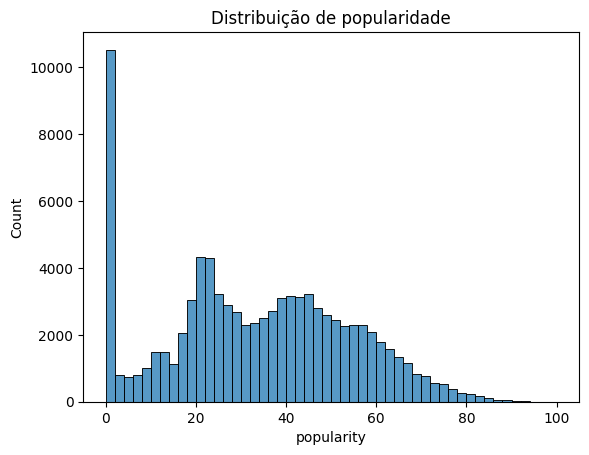

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df["popularity"], bins = 50)
plt.title("Distribuição de popularidade")
plt.show()

- A massa está concentrada na casa dos 30
- Tem um pico gigantesco de músicas com popularidade 0
- A distribuição é assimétrica para direita

In [8]:
print(f"Quantidade de faixas com nota zero: {(df['popularity'] == 0).sum()}")

Quantidade de faixas com nota zero: 9443


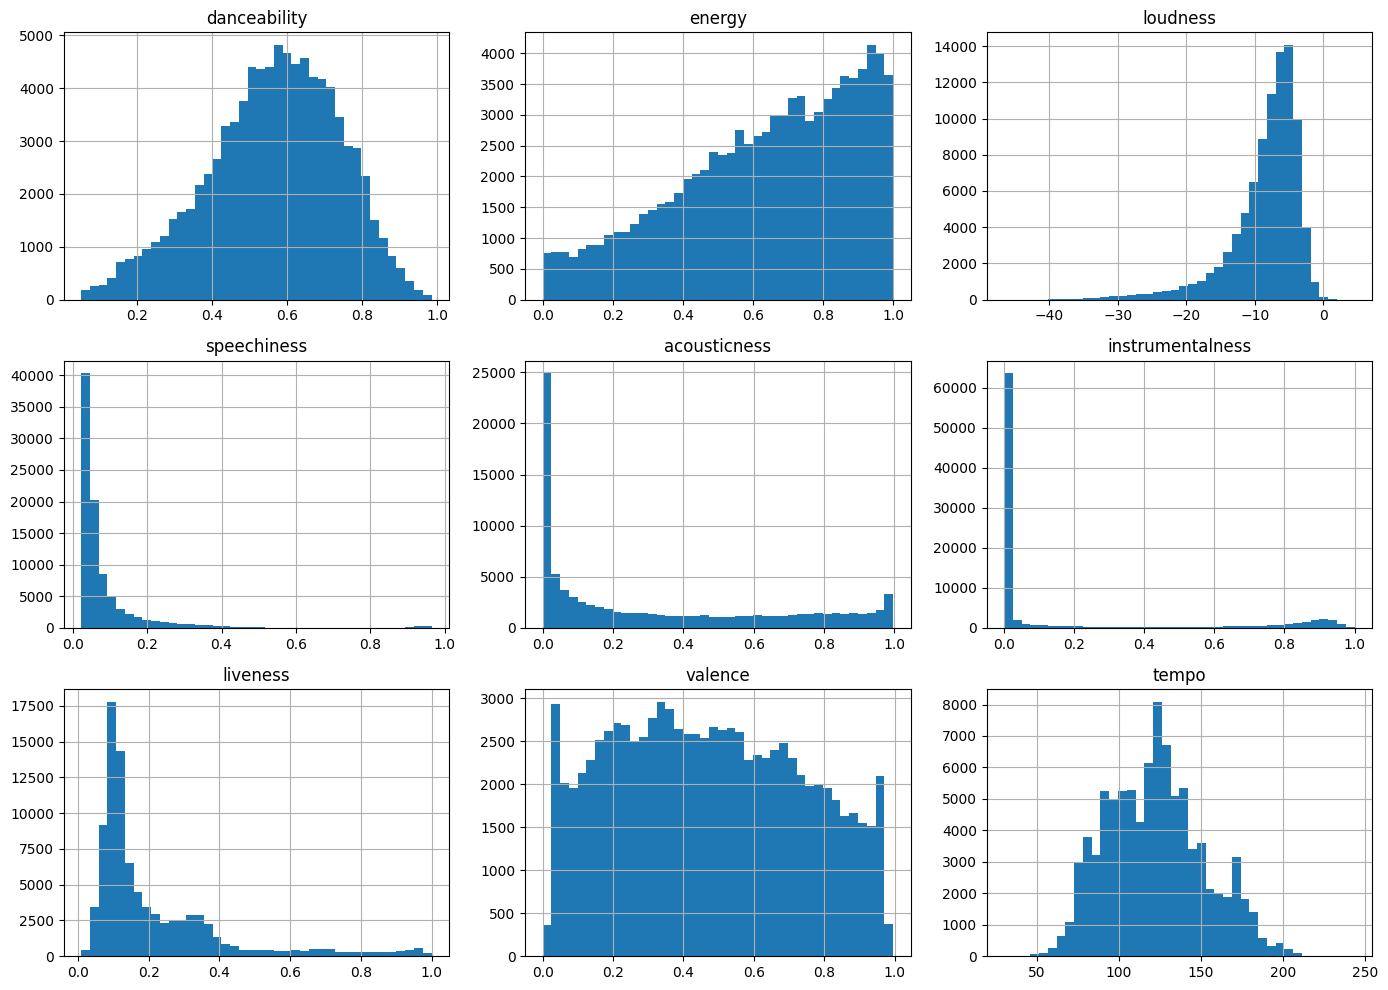

In [9]:
features = ['danceability', 'energy',
        'loudness', 'speechiness', 'acousticness',
        'instrumentalness', 'liveness', 'valence', 'tempo']
df[features].hist(bins=40, figsize=(14,10))
plt.tight_layout()
plt.show()

## 4. Relações com a popularidade

**Correlação linear (Pearson):** toda a linha de `popularity` ficou próxima de zero
(maior magnitude: `instrumentalness`, −0,10). Ou seja, nenhuma feature de áudio explica
linearmente a popularidade. Entre as próprias features há um eixo colinear forte:
`energy`↔`loudness` (+0,76) e `energy`↔`acousticness` (−0,73).

**Comparação por faixa de popularidade:** como Pearson só captura relações lineares,
as features foram comparadas entre tiers de popularidade. O padrão só aparece no topo
(76–100, 1.280 faixas, 1,4%): hits são mais altos (loudness ~−6 vs ~−8), menos acústicos,
com voz (`instrumentalness` ~0) e mais dançáveis. Os boxplots confirmam que a distribuição
inteira se desloca, não apenas a média. O restante da escala é homogêneo — por isso a
correlação linear não enxergava o sinal, que é não-linear e concentrado na ponta.

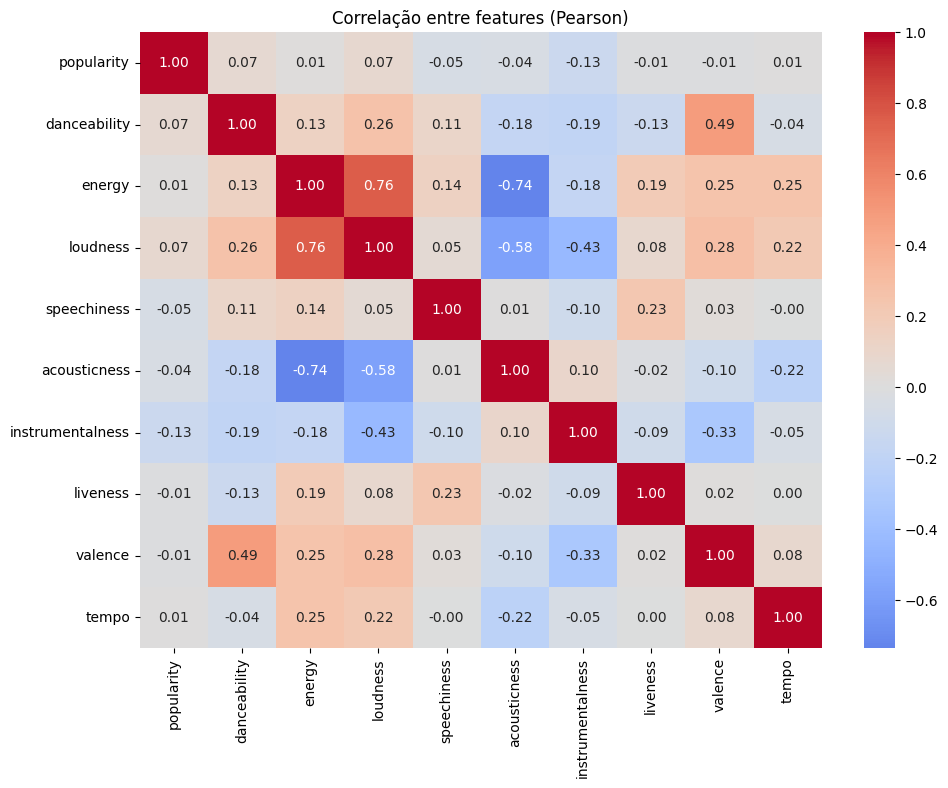

In [11]:
num = ['popularity', 'danceability', 'energy',
        'loudness', 'speechiness', 'acousticness',
        'instrumentalness', 'liveness', 'valence', 'tempo']
plt.figure(figsize=(11,8))
sns.heatmap(df[num].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlação entre features (Pearson)")
plt.show()

- Nenhuma correlação forte entre popularidade e as features
- Multicolinearidade entre energy, loudness e acousticness

In [12]:
#Comparação de features entre faixas populares e impopulares diretamente
df["pop_bin"] = pd.cut(df["popularity"], bins=[-1,0,25,50,75,100],
                       labels=["0","1-25","26-50","51-75","76-100"])

(df.groupby("pop_bin")[["danceability","energy","loudness",
                        "acousticness","instrumentalness","valence"]]
   .mean().round(3))

/tmp/ipykernel_32823/914484656.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  (df.groupby("pop_bin")[["danceability","energy","loudness",


,danceability,energy,loudness,acousticness,instrumentalness,valence
pop_bin,,,,,,
0,0.557,0.580,-8.900,0.388,0.126,0.484
1-25,0.542,0.651,-8.967,0.318,0.272,0.450
26-50,0.570,0.646,-8.160,0.331,0.144,0.490
51-75,0.577,0.620,-8.319,0.312,0.125,0.451
76-100,0.642,0.669,-6.389,0.210,0.026,0.515


In [13]:
df["pop_bin"].value_counts()    # quantas faixas tem cada tier?

pop_bin
26-50     34779
1-25      25424
51-75     18652
0          9443
76-100     1280
Name: count, dtype: int64

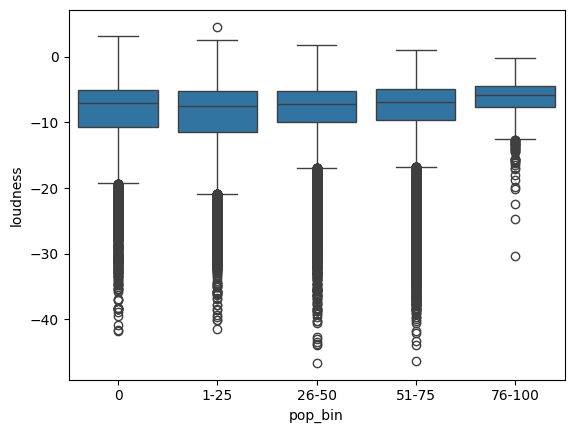

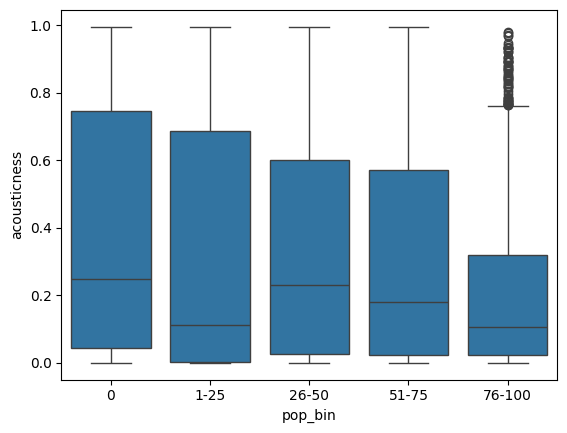

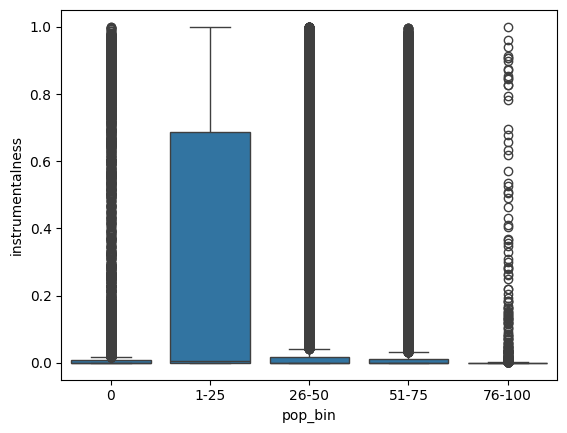

In [14]:
import matplotlib.pyplot as plt
for col in ["loudness", "acousticness", "instrumentalness"]:
    sns.boxplot(data=df, x="pop_bin", y=col)
    plt.show()

## 5. Conclusões

As características sonoras de uma música quase não explicam sua popularidade de forma
linear. Os principais motores do sucesso — fama do artista, presença em playlists,
marketing, viralização, recência — não estão no dataset.

Há, porém, um padrão não-linear: os hits compartilham um perfil sonoro nítido e
consistente (altos, produzidos, vocais, dançáveis), enquanto o resto da escala é uniforme.
Esse perfil é **necessário mas não suficiente**: a vasta maioria das faixas que o seguem
não é popular. A popularidade é, em grande parte, exógena ao áudio.

## Limitações

- `popularity` é uma métrica temporal (streams recentes), não qualidade intrínseca.
- Análise correlacional, não causal: o "perfil de hit" reflete normas de produção atuais,
  não uma receita de sucesso.
- Os principais determinantes da popularidade não estão no dataset.
- A deduplicação manteve apenas o primeiro gênero de cada faixa, descartando a informação
  multi-gênero — adequado à pergunta, mas é uma escolha que limita análises por gênero.